# Gaussian Mixture Models (GMM) Implementation
Assignment: Unsupervised Learning - Breast Cancer Wisconsin Dataset

This implementation includes:  
1. GMM from scratch with all covariance types
2. Model selection using AIC & BIC
3. PCA + GMM analysis
4. Autoencoder + GMM analysis
5. Comprehensive evaluation metrics 
### Imports and Setting Random Seeds 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix
)
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Load and preprocess the Breast Cancer Wisconsin dataset.
    Steps:
    1. Load dataset from sklearn
    2. Convert to DataFrame for easier manipulation
    3. Check for missing values
    4. Standardize features (critical for GMM)

### **Standardization**
- Implemented the Standard Scaler function manually ```manual_standard_scaler(X)``` using X_scaled = (X - mean) / std
- Why standardization is important:
  - Features with larger scales would dominate without standardization the Gaussian probability calculations
  - Covariance matrices would be poorly conditioned
  - EM algorithm might not converge properly
  - with std. , all features will contribute equally with mean = 0 and std=1

- In the breastcancer dataset there are no missing data.

In [155]:
def manual_standard_scaler(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    # Avoid division by zero
    std[std == 0] = 1.0

    X_scaled = (X - mean) / std
    return X_scaled, mean, std

def load_and_preprocess_data():
    print("="*80)
    print("LOADING AND PREPROCESSING DATA")
    print("="*80)
    
    # Load dataset from sklearn 
    data = load_breast_cancer()
    X = data.data
    y = data.target  # 0 = malignant, 1 = benign
    feature_names = data.feature_names
    
    print(f"Dataset shape: {X.shape}")
    print(f"Number of samples: {X.shape[0]}")
    print(f"Number of features: {X.shape[1]}")
    print(f"\nClass distribution:")
    print(f"  Malignant (0): {np.sum(y == 0)} samples")
    print(f"  Benign (1): {np.sum(y == 1)} samples")
    
    # Check for missing values
    df = pd.DataFrame(X, columns=feature_names)
    missing_values = df.isnull().sum().sum()
    print(f"\nMissing values: {missing_values}")
    
    # Standardize features (mean=0, std=1) which is crucial for GMM as it's sensitive to feature scales
    X_scaled, mean, std = manual_standard_scaler(X)
    
    print(
        f"Feature means after scaling: "
        f"min={X_scaled.mean(axis=0).min():.6f}, "
        f"max={X_scaled.mean(axis=0).max():.6f}"
    )
    print(
        f"Feature stds after scaling: "
        f"min={X_scaled.std(axis=0).min():.6f}, "
        f"max={X_scaled.std(axis=0).max():.6f}"
    )

    return X_scaled, y, feature_names

## CLUSTERING EVALUATION METRICS (MANUAL IMPLEMENTATION)

**Silhouette Score (s):**
- How similar a sample is to its own cluster compared to the nearest other cluster.	
- Range: [-1,1]. Higher is better. 
  - s ≈ 1 → sample is well matched
  - s ≈ 0 → near boundary
  - s < 0 → likely misclassified. 
- Useful for detecting cluster separation.  

**Davies-Bouldin Index (DB)**
- Ratio of intra-cluster dispersion to inter-cluster separation.	
- Range: [0,∞). 
- Lower is better. 
- Smaller values indicate clusters are compact and well-separated.

**Calinski-Harabasz Index (CH)**
- Ratio of between-cluster variance to within-cluster variance.	
- Higher is better. 
- Measures how distinct the clusters are. 
- Larger CH → tight and well-separated clusters.

**WCSS (Within-Cluster Sum of Squares)**	
- Sum of squared distances between samples and their cluster centroid.	
- Lower is better. 
- Direct measure of cluster compactness. 
- Useful for elbow method to choose number of clusters (K).

In [ ]:
def silhouette_score_manual(X, labels):
    n_samples = X.shape[0]
    unique_labels = np.unique(labels)
    s = np.zeros(n_samples)
    
    for i in range(n_samples):
        same_cluster = X[labels == labels[i]]
        other_clusters = [X[labels == l] for l in unique_labels if l != labels[i]]
        
        # a(i): mean intra-cluster distance
        if len(same_cluster) > 1:
            a = np.mean(np.linalg.norm(same_cluster - X[i], axis=1))
        else:
            a = 0
        
        # b(i): mean nearest-cluster distance
        b = np.min([np.mean(np.linalg.norm(cluster - X[i], axis=1)) for cluster in other_clusters])
        
        s[i] = (b - a) / max(a, b) if max(a, b) > 0 else 0
    
    return np.mean(s)

def davies_bouldin_score_manual(X, labels):
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    centroids = np.array([X[labels==l].mean(axis=0) for l in unique_labels])
    cluster_sigs = np.array([np.mean(np.linalg.norm(X[labels==l]-centroids[i], axis=1))
                             for i, l in enumerate(unique_labels)])
    
    db_index = 0
    for i in range(n_clusters):
        max_ratio = 0
        for j in range(n_clusters):
            if i != j:
                dist = np.linalg.norm(centroids[i]-centroids[j])
                if dist > 0:
                    ratio = (cluster_sigs[i] + cluster_sigs[j]) / dist
                    max_ratio = max(max_ratio, ratio)
        db_index += max_ratio
    return db_index / n_clusters

def calinski_harabasz_score_manual(X, labels):
    n_samples, n_features = X.shape
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    overall_mean = np.mean(X, axis=0)
    
    # Between-cluster sum of squares
    B = sum([len(X[labels==l]) * np.sum((X[labels==l].mean(axis=0) - overall_mean)**2)
             for l in unique_labels])
    
    # Within-cluster sum of squares
    W = sum([np.sum((X[labels==l] - X[labels==l].mean(axis=0))**2)
             for l in unique_labels])
    
    if W == 0 or n_clusters == 1:
        return 0
    return (B / (n_clusters - 1)) / (W / (n_samples - n_clusters))

def wcss_manual(X, labels):
    unique_labels = np.unique(labels)
    wcss = sum([np.sum((X[labels==l] - X[labels==l].mean(axis=0))**2) for l in unique_labels])
    return wcss

def comb_manual(n, k):
    """Calculate binomial coefficient manually."""
    if n < k or k < 0:
        return 0
    if k == 0 or k == n:
        return 1
    # Use multiplicative formula to avoid overflow
    result = 1
    for i in range(min(k, n - k)):
        result = result * (n - i) // (i + 1)
    return result

def adjusted_rand_score_manual(labels_true, labels_pred):
    """Calculate Adjusted Rand Index manually without scipy."""
    contingency = confusion_matrix(labels_true, labels_pred)
    
    # Calculate combinatorial sums
    sum_comb_c = sum([comb_manual(int(n_ij), 2) 
                      for n_ij in contingency.flatten()])
    sum_comb_k = sum([comb_manual(int(n), 2) 
                      for n in contingency.sum(axis=1)])
    sum_comb_c_prime = sum([comb_manual(int(n), 2) 
                           for n in contingency.sum(axis=0)])
    
    n = int(contingency.sum())
    comb_n = comb_manual(n, 2)
    
    if comb_n == 0:
        return 0
    
    expected_index = (sum_comb_k * sum_comb_c_prime) / comb_n
    max_index = (sum_comb_k + sum_comb_c_prime) / 2
    
    if max_index - expected_index == 0:
        return 0
    
    ari = (sum_comb_c - expected_index) / (max_index - expected_index)
    return ari

def normalized_mutual_info_score_manual(labels_true, labels_pred):
    """Calculate Normalized Mutual Information manually."""
    contingency = confusion_matrix(labels_true, labels_pred)
    
    # Marginal distributions
    pi = contingency.sum(axis=1) / contingency.sum()
    pj = contingency.sum(axis=0) / contingency.sum()
    
    # Joint distribution
    pij = contingency / contingency.sum()
    
    # Mutual Information
    mi = 0
    for i in range(len(pi)):
        for j in range(len(pj)):
            if pij[i, j] > 0:
                mi += pij[i, j] * np.log(pij[i, j] / (pi[i] * pj[j]))
    
    # Entropy
    h_true = -np.sum(pi * np.log(pi + 1e-10))
    h_pred = -np.sum(pj * np.log(pj + 1e-10))
    
    # Normalized MI
    nmi = mi / np.sqrt(h_true * h_pred) if h_true * h_pred > 0 else 0
    return nmi

In [ ]:
def normalized_mutual_info_score_manual(labels_true, labels_pred):
    """Calculate Normalized Mutual Information manually."""
    contingency = confusion_matrix(labels_true, labels_pred)
    
    # Marginal distributions
    pi = contingency.sum(axis=1) / contingency.sum()
    pj = contingency.sum(axis=0) / contingency.sum()
    
    # Joint distribution
    pij = contingency / contingency.sum()
    
    # Mutual Information
    mi = 0
    for i in range(len(pi)):
        for j in range(len(pj)):
            if pij[i, j] > 0:
                mi += pij[i, j] * np.log(pij[i, j] / (pi[i] * pj[j]))
    
    # Entropy
    h_true = -np.sum(pi * np.log(pi + 1e-10))
    h_pred = -np.sum(pj * np.log(pj + 1e-10))
    
    # Normalized MI
    nmi = mi / np.sqrt(h_true * h_pred) if h_true * h_pred > 0 else 0
    return nmi

def plot_elbow_curve(X, k_range, metric='wcss'):
    """Plot elbow curve for K-means/GMM."""
    scores = []
    
    for k in k_range:
        gmm = GaussianMixtureModel(n_components=k, random_state=RANDOM_SEED)
        gmm.fit(X)
        labels = gmm.predict(X)
        
        if metric == 'wcss':
            score = wcss_manual(X, labels)
        elif metric == 'silhouette':
            score = silhouette_score_manual(X, labels)
        
        scores.append(score)
    
    # Find elbow using second derivative
    diffs = np.diff(scores)
    second_diffs = np.diff(diffs)
    elbow_idx = np.argmax(second_diffs) + 1
    optimal_k = k_range[elbow_idx]
    
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, scores, marker='o', linewidth=2)
    plt.axvline(optimal_k, color='red', linestyle='--', 
                label=f'Optimal K = {optimal_k}')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel(metric.upper())
    plt.title(f'Elbow Curve - {metric.upper()}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
def plot_2d_projections_all_methods(X, y, results_dict):
    """Plot 2D projections for all dimensionality reduction methods."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()
    
    methods = ['PCA_2', 'PCA_5', 'PCA_10', 'AE_2', 'AE_5', 'AE_10']
    
    for idx, method in enumerate(methods):
        ax = axes[idx]
        
        # Get 2D projection
        X_2d = results_dict[method]['X_reduced'][:, :2]
        labels = results_dict[method]['cluster_labels']
        
        # Plot clusters
        scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], 
                            c=labels, cmap='viridis', alpha=0.6, s=20)
        
        # Plot true labels as background
        ax.scatter(X_2d[:, 0], X_2d[:, 1], 
                  c=y, cmap='RdYlBu', alpha=0.2, s=10, marker='x')
        
        ax.set_title(f'{method}')
        ax.set_xlabel('Dimension 1')
        ax.set_ylabel('Dimension 2')
        plt.colorbar(scatter, ax=ax)
    
    plt.tight_layout()
    plt.show()
    
def plot_comprehensive_heatmap(results_df):
    """Create heatmap comparing all methods across all metrics."""
    metrics = ['Silhouette', 'Davies_Bouldin', 'Calinski_Harabasz', 
               'ARI', 'NMI', 'Purity', 'WCSS']
    
    # Normalize metrics (some higher is better, some lower)
    heatmap_data = results_df.pivot_table(
        index='Method', 
        columns='Metric', 
        values='Score'
    )
    
    # Normalize each metric to 0-1
    for col in heatmap_data.columns:
        if col in ['Davies_Bouldin', 'WCSS']:
            # Lower is better
            heatmap_data[col] = 1 - (heatmap_data[col] - heatmap_data[col].min()) / \
                                (heatmap_data[col].max() - heatmap_data[col].min())
        else:
            # Higher is better
            heatmap_data[col] = (heatmap_data[col] - heatmap_data[col].min()) / \
                                (heatmap_data[col].max() - heatmap_data[col].min())
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
                cbar_kws={'label': 'Normalized Score'})
    plt.title('Comprehensive Method Comparison Across All Metrics')
    plt.xlabel('Metrics')
    plt.ylabel('Methods')
    plt.tight_layout()
    plt.show()

## PCA

In [156]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        # Mean centering
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Covariance matrix
        cov = np.cov(X_centered, rowvar=False)

        # Eigen decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # Sort eigenvalues & eigenvectors descending
        idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[idx]
        self.eigenvectors = eigenvectors[:, idx]

        # Select principal components
        self.components = self.eigenvectors[:, :self.n_components]

        # Explained variance ratio
        self.explained_variance_ratio = (
            self.eigenvalues[:self.n_components] / np.sum(self.eigenvalues)
        )

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def inverse_transform(self, X_reduced):
        return np.dot(X_reduced, self.components.T) + self.mean

    def reconstruction_error(self, X):
        X_recon = self.inverse_transform(self.transform(X))
        return np.mean((X - X_recon) ** 2)
    
# Utitlity functions for clustering metrics 
def wcss(X, labels):
    clusters = np.unique(labels)
    return sum(np.sum((X[labels == c] - X[labels == c].mean(axis=0))**2) for c in clusters)

def purity_score(y_true, y_pred):
    # Purity = sum of majority class in each cluster / total samples
    contingency_matrix = confusion_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)


## AUTOENCODER

In [157]:
# Activation functions and derivatives
from tabnanny import verbose


def tanh(x): return np.tanh(x)
def tanh_deriv(x): return 1 - np.tanh(x) ** 2

def relu(x): return np.maximum(0, x)
def relu_deriv(x): return (x > 0).astype(float)

def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_deriv(x): s = sigmoid(x); return s * (1 - s)

def linear(x): return x
def linear_deriv(x): return np.ones_like(x)

activation_map = {
    'tanh': (tanh, tanh_deriv),
    'relu': (relu, relu_deriv),
    'sigmoid': (sigmoid, sigmoid_deriv),
    'linear': (linear, linear_deriv)
}

def calculate_silhouette_score(X, labels):
    """
    Compute silhouette score for clustering manually.
    
    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_features)
        Data points.
    labels : np.ndarray, shape (n_samples,)
        Cluster labels for each point.
        
    Returns
    -------
    float
        Mean silhouette score for all samples.
    """
    n_samples = X.shape[0]
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    silhouette_scores = np.zeros(n_samples)
    
    for i in range(n_samples):
        own_label = labels[i]
        own_cluster = X[labels == own_label]
        a = np.mean([np.linalg.norm(X[i] - x) for x in own_cluster if not np.array_equal(X[i], x)])
        
        b = np.inf
        for label in unique_labels:
            if label == own_label:
                continue
            other_cluster = X[labels == label]
            if len(other_cluster) > 0:
                b = min(b, np.mean([np.linalg.norm(X[i] - x) for x in other_cluster]))
        
        silhouette_scores[i] = 0 if max(a, b) == 0 else (b - a) / max(a, b)
    
    return np.mean(silhouette_scores)



class Autoencoder:
    def __init__(self, layer_sizes, activations=None, lr=0.005, l2=1e-4):
        """
        layer_sizes: list of integers, e.g., [input, 128, 64, bottleneck, 64, 128, input]
        activations: list of strings, e.g., ['tanh', 'relu', 'tanh', 'relu', 'linear']
        """
        self.layer_sizes = layer_sizes
        self.lr = lr
        self.l2 = l2
        self.weights = []
        self.biases = []
        self.activations = activations or ['tanh'] * (len(layer_sizes)-2) + ['linear']
        
        if len(self.activations) != len(layer_sizes) - 1:
            raise ValueError("activations length must match number of layers minus 1")

        # Xavier or small initialization
        for i in range(len(layer_sizes) - 1):
            if self.activations[i] == 'linear':
                W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01
            else:
                W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(1 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(W)
            self.biases.append(b)

    # Forward pass
    def forward(self, X):
        activations = [X]
        zs = []
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = activations[-1] @ W + b
            zs.append(z)
            act_func = activation_map[self.activations[i]][0]
            activations.append(act_func(z))
        return activations, zs

    # Backpropagation
    def backward(self, X, activations, zs):
        grads_W = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)
        
        # Error at output layer
        delta = activations[-1] - X
        for i in reversed(range(len(self.weights))):
            grads_W[i] = activations[i].T @ delta + self.l2 * self.weights[i]
            grads_b[i] = np.sum(delta, axis=0, keepdims=True)
            if i > 0:
                deriv_func = activation_map[self.activations[i-1]][1]
                delta = (delta @ self.weights[i].T) * deriv_func(zs[i-1])
        return grads_W, grads_b

    # Training
    def train(self, X, epochs=150, batch_size=32, lr_decay=0.995, verbose=False):
        n = X.shape[0]
        loss_history = []
    
        for epoch in range(epochs):
            perm = np.random.permutation(n)
            X_shuffled = X[perm]
            for i in range(0, n, batch_size):
                batch = X_shuffled[i:i + batch_size]
                activations, zs = self.forward(batch)
                grads_W, grads_b = self.backward(batch, activations, zs)
                for j in range(len(self.weights)):
                    self.weights[j] -= self.lr * grads_W[j]
                    self.biases[j] -= self.lr * grads_b[j]
        
            self.lr *= lr_decay
            loss = np.mean((self.forward(X)[0][-1] - X) ** 2)
            loss_history.append(loss)

            if verbose and epoch % 30 == 0:
                print(f"Epoch {epoch}, Loss = {loss:.5f}")
    
        return loss_history

    # Encode (bottleneck)
    def encode(self, X):
        mid = len(self.layer_sizes) // 2
        activations, _ = self.forward(X)
        return activations[mid]

    # Reconstruct
    def reconstruct(self, X):
        return self.forward(X)[0][-1]


## GAUSSIAN MIXTURE MODEL

In [158]:
class GaussianMixtureModel:
    """
    Gaussian Mixture Model implementation from scratch using EM algorithm.
    
    Supports four covariance types:
    - 'full': Each component has its own general covariance matrix
    - 'tied': All components share the same general covariance matrix
    - 'diagonal': Each component has its own diagonal covariance matrix
    - 'spherical': Each component has its own single variance value
    
    Parameters:
    -----------
    n_components : int
        Number of Gaussian components
    covariance_type : str
        Type of covariance parameters ('full', 'tied', 'diagonal', 'spherical')
    max_iter : int
        Maximum number of EM iterations
    tol : float
        Convergence threshold for log-likelihood
    reg_covar : float
        Regularization added to diagonal of covariance matrices for numerical stability
    random_state : int or None
        Random seed for reproducibility
    """
    
    def __init__(self, n_components=2, covariance_type='full', max_iter=100, 
                 tol=1e-3, reg_covar=1e-6, random_state=None):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        self.random_state = random_state
        
        # Model parameters (initialized during fit)
        self.weights = None  # Mixing coefficients (pi)
        self.means = None    # Component means (mu)
        self.covariances = None  # Component covariances (Sigma)
        
        # Training history
        self.converged = False
        self.n_iter = 0
        self.log_likelihood_history = []
        
    def _initialize_parameters(self, X):
        """
        Initialize GMM parameters using K-means++ strategy for means.
        
        Strategy:
        - Weights: Uniform distribution (1/K for each component)
        - Means: K-means++ initialization for better starting points
        - Covariances: Based on global data covariance, scaled by covariance type
        """
        n_samples, n_features = X.shape
        
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        # Initialize weights uniformly
        self.weights = np.ones(self.n_components) / self.n_components
        
        # Initialize means using k-means++ strategy
        self.means = self._kmeans_plusplus_init(X)
        
        # Initialize covariances based on type
        if self.covariance_type == 'full':
            # Each component gets the global covariance matrix
            global_cov = np.cov(X.T) + self.reg_covar * np.eye(n_features)
            self.covariances = np.array([global_cov for _ in range(self.n_components)])
            
        elif self.covariance_type == 'tied':
            # Single shared covariance matrix
            self.covariances = np.cov(X.T) + self.reg_covar * np.eye(n_features)
            
        elif self.covariance_type == 'diagonal':
            # Diagonal covariance matrices
            global_var = np.var(X, axis=0) + self.reg_covar
            self.covariances = np.array([np.diag(global_var) for _ in range(self.n_components)])
            
        elif self.covariance_type == 'spherical':
            # Single variance per component (isotropic)
            global_var = np.mean(np.var(X, axis=0)) + self.reg_covar
            self.covariances = np.array([global_var for _ in range(self.n_components)])
    
    def _kmeans_plusplus_init(self, X):
        """
        K-means++ initialization for cluster centers.
        
        This provides better initial means than random selection:
        1. Choose first center randomly
        2. For each subsequent center, choose with probability proportional 
           to squared distance from nearest existing center
        """
        n_samples, n_features = X.shape
        centers = np.zeros((self.n_components, n_features))
        
        # First center: random sample
        centers[0] = X[np.random.randint(n_samples)]
        
        # Subsequent centers
        for k in range(1, self.n_components):
            # Compute distances to nearest center
            distances = np.min([np.sum((X - centers[j])**2, axis=1) 
                               for j in range(k)], axis=0)
            
            # Choose next center with probability proportional to distance squared
            probabilities = distances / distances.sum()
            cumulative_probs = np.cumsum(probabilities)
            r = np.random.rand()
            
            for idx, cum_prob in enumerate(cumulative_probs):
                if r < cum_prob:
                    centers[k] = X[idx]
                    break
        
        return centers
    
    def _compute_log_gaussian_prob(self, X, means, covariances):
        """
        Compute log probability of X under multivariate Gaussian.
        
        For numerical stability, we compute in log space:
        log N(x|μ,Σ) = -0.5 * [d*log(2π) + log|Σ| + (x-μ)ᵀΣ⁻¹(x-μ)]
        
        Returns: log_prob of shape (n_samples, n_components)
        """
        n_samples, n_features = X.shape
        n_components = len(means)
        log_prob = np.zeros((n_samples, n_components))
        
        for k in range(n_components):
            diff = X - means[k]
            
            if self.covariance_type == 'full':
                cov = covariances[k]
                # Add regularization for numerical stability
                cov_reg = cov + self.reg_covar * np.eye(n_features)
                
                try:
                    # Cholesky decomposition for efficient computation
                    L = np.linalg.cholesky(cov_reg)
                    log_det = 2 * np.sum(np.log(np.diagonal(L)))
                    
                    # Solve L @ y = diff.T for y, then compute ||y||²
                    y = np.linalg.solve(L, diff.T)
                    mahalanobis = np.sum(y**2, axis=0)
                    
                except np.linalg.LinAlgError:
                    # Fallback to SVD if Cholesky fails
                    U, s, Vt = np.linalg.svd(cov_reg)
                    log_det = np.sum(np.log(s))
                    inv_cov = Vt.T @ np.diag(1.0 / s) @ U.T
                    mahalanobis = np.sum(diff @ inv_cov * diff, axis=1)
                
            elif self.covariance_type == 'tied':
                cov_reg = covariances + self.reg_covar * np.eye(n_features)
                
                try:
                    L = np.linalg.cholesky(cov_reg)
                    log_det = 2 * np.sum(np.log(np.diagonal(L)))
                    y = np.linalg.solve(L, diff.T)
                    mahalanobis = np.sum(y**2, axis=0)
                except np.linalg.LinAlgError:
                    U, s, Vt = np.linalg.svd(cov_reg)
                    log_det = np.sum(np.log(s))
                    inv_cov = Vt.T @ np.diag(1.0 / s) @ U.T
                    mahalanobis = np.sum(diff @ inv_cov * diff, axis=1)
                
            elif self.covariance_type == 'diagonal':
                # Diagonal: variance on diagonal
                variances = np.diagonal(covariances[k]) + self.reg_covar
                log_det = np.sum(np.log(variances))
                mahalanobis = np.sum((diff**2) / variances, axis=1)
                
            elif self.covariance_type == 'spherical':
                # Spherical: single variance value
                variance = covariances[k] + self.reg_covar
                log_det = n_features * np.log(variance)
                mahalanobis = np.sum(diff**2, axis=1) / variance
            
            # Compute log probability
            log_prob[:, k] = -0.5 * (n_features * np.log(2 * np.pi) + log_det + mahalanobis)
        
        return log_prob


    def _e_step(self, X):
        """
        E-step: Compute responsibilities (posterior probabilities).
        
        Responsibility γ(znk) = P(component k | data point n)
                               = π_k * N(xn|μk,Σk) / Σj[πj * N(xn|μj,Σj)]
        
        Returns: responsibilities of shape (n_samples, n_components)
        """
        # Compute log probabilities
        log_prob = self._compute_log_gaussian_prob(X, self.means, self.covariances)
        
        # Add log weights: log[π_k * N(x|μk,Σk)] = log(π_k) + log N(x|μk,Σk)
        log_weighted_prob = log_prob + np.log(self.weights + 1e-10)
        
        # Compute log of denominator using log-sum-exp trick for numerical stability
        log_prob_norm = self._log_sum_exp(log_weighted_prob, axis=1, keepdims=True)
        
        # Compute responsibilities in log space then exponentiate
        log_resp = log_weighted_prob - log_prob_norm
        responsibilities = np.exp(log_resp)
        
        return responsibilities
    
    def _m_step(self, X, responsibilities):
        """
        M-step: Update parameters to maximize expected log-likelihood.
        
        Updates:
        - Weights: π_k = N_k / N (proportion of data assigned to component k)
        - Means: μ_k = (1/N_k) * Σn[γ(znk) * xn]
        - Covariances: Σ_k = (1/N_k) * Σn[γ(znk) * (xn-μk)(xn-μk)ᵀ]
        """
        n_samples, n_features = X.shape
        
        # Effective number of points assigned to each component
        N_k = responsibilities.sum(axis=0) + 1e-10
        
        # Update weights
        self.weights = N_k / n_samples
        
        # Update means
        self.means = (responsibilities.T @ X) / N_k[:, np.newaxis]

        # Update covariances based on type
        if self.covariance_type == 'full':
            self.covariances = np.zeros((self.n_components, n_features, n_features))
            for k in range(self.n_components):
                diff = X - self.means[k]
                # Weighted covariance
                self.covariances[k] = (responsibilities[:, k:k+1] * diff).T @ diff / N_k[k]
                # Add regularization
                self.covariances[k] += self.reg_covar * np.eye(n_features)
        
        elif self.covariance_type == 'tied':
            self.covariances = np.zeros((n_features, n_features))
            for k in range(self.n_components):
                diff = X - self.means[k]
                self.covariances += (responsibilities[:, k:k+1] * diff).T @ diff
            self.covariances /= n_samples
            self.covariances += self.reg_covar * np.eye(n_features)
        
        elif self.covariance_type == 'diagonal':
            self.covariances = np.zeros((self.n_components, n_features, n_features))
            for k in range(self.n_components):
                diff = X - self.means[k]
                # Diagonal covariance: only compute variances
                variances = np.sum(responsibilities[:, k:k+1] * diff**2, axis=0) / N_k[k]
                self.covariances[k] = np.diag(variances + self.reg_covar)
        
        elif self.covariance_type == 'spherical':
            self.covariances = np.zeros(self.n_components)
            for k in range(self.n_components):
                diff = X - self.means[k]
                # Spherical: average variance across dimensions
                variance = np.sum(responsibilities[:, k:k+1] * diff**2) / (N_k[k] * n_features)
                self.covariances[k] = variance + self.reg_covar
    
    def _compute_log_likelihood(self, X):
        """
        Compute log-likelihood of the data.
        
        log L = Σn log[Σk πk * N(xn|μk,Σk)]
        
        Used for monitoring convergence.
        """
        log_prob = self._compute_log_gaussian_prob(X, self.means, self.covariances)
        log_weighted_prob = log_prob + np.log(self.weights + 1e-10)
        log_likelihood = np.sum(self._log_sum_exp(log_weighted_prob, axis=1))
        return log_likelihood
    
    @staticmethod
    def _log_sum_exp(arr, axis=None, keepdims=False):
        """
        Compute log(sum(exp(arr))) in a numerically stable way.
        
        Uses the log-sum-exp trick:
        log(Σ exp(xi)) = log(exp(a) * Σ exp(xi - a)) = a + log(Σ exp(xi - a))
        where a = max(xi)
        """
        arr_max = np.max(arr, axis=axis, keepdims=True)
        
        if arr_max.ndim > 0:
            arr_max[~np.isfinite(arr_max)] = 0
        elif not np.isfinite(arr_max):
            arr_max = 0
        
        out = np.log(np.sum(np.exp(arr - arr_max), axis=axis, keepdims=keepdims))
        out += np.squeeze(arr_max, axis=axis) if not keepdims else arr_max
        
        return out
    
    def fit(self, X):
        """
        Fit GMM using the EM algorithm.
        
        EM Algorithm:
        1. Initialize parameters
        2. Repeat until convergence:
           a. E-step: Compute responsibilities
           b. M-step: Update parameters
           c. Compute log-likelihood
           d. Check convergence
        """
        # Initialize parameters
        self._initialize_parameters(X)
        
        # Initial log-likelihood
        log_likelihood = self._compute_log_likelihood(X)
        self.log_likelihood_history_ = [log_likelihood]
        
        # EM iterations
        for iteration in range(self.max_iter):
            # E-step
            responsibilities = self._e_step(X)
            
            # M-step
            self._m_step(X, responsibilities)
            
            # Compute new log-likelihood
            log_likelihood = self._compute_log_likelihood(X)
            self.log_likelihood_history_.append(log_likelihood)
            
            # Check convergence
            log_likelihood_change = abs(log_likelihood - self.log_likelihood_history_[-2])
            
            if log_likelihood_change < self.tol:
                self.converged_ = True
                self.n_iter_ = iteration + 1
                break
        
        if not self.converged_:
            self.n_iter_ = self.max_iter
            print(f"Warning: Algorithm did not converge in {self.max_iter} iterations")
        
        return self
    
    def predict(self, X):
        """
        Predict cluster labels for samples.
        
        Returns the component with highest responsibility for each sample.
        """
        responsibilities = self._e_step(X)
        return np.argmax(responsibilities, axis=1)
    
    def predict_proba(self, X):
        """
        Predict posterior probabilities for each component.
        
        Returns: responsibilities (soft assignments) for each sample
        """
        return self._e_step(X)
    
    def score(self, X):
        """
        Compute the average log-likelihood per sample.
        
        This is a measure of how well the model fits the data.
        """
        return self._compute_log_likelihood(X) / len(X)

In [159]:
def plot_convergence(models, results):
    """
    Plot log-likelihood convergence for all covariance types.
    """
    plt.figure(figsize=(12, 6))
    
    for cov_type in models.keys():
        history = models[cov_type].log_likelihood_history_
        plt.plot(history, marker='o', markersize=4, label=f'{cov_type}', linewidth=2)
    
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Log-Likelihood', fontsize=12)
    plt.title('GMM Convergence: Log-Likelihood vs Iteration', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('gmm_convergence.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nConvergence plot saved as 'gmm_convergence.png'")


def plot_cluster_distributions(X, results, y_true):
    """
    Plot cluster assignments vs true labels for all covariance types.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.ravel()
    
    covariance_types = list(results.keys())
    
    for idx, cov_type in enumerate(covariance_types):
        ax = axes[idx]
        labels_pred = results[cov_type]['labels']
        
        # Create confusion-like visualization
        unique_pred = np.unique(labels_pred)
        unique_true = np.unique(y_true)
        
        confusion = np.zeros((len(unique_true), len(unique_pred)))
        for i, true_label in enumerate(unique_true):
            for j, pred_label in enumerate(unique_pred):
                confusion[i, j] = np.sum((y_true == true_label) & (labels_pred == pred_label))
        
        sns.heatmap(confusion, annot=True, fmt='.0f', cmap='Blues', ax=ax,
                   xticklabels=[f'Cluster {i}' for i in unique_pred],
                   yticklabels=['Malignant', 'Benign'],
                   cbar_kws={'label': 'Count'})
        
        ax.set_title(f"'{cov_type}' Covariance\nLog-likelihood: {results[cov_type]['avg_log_likelihood']:.4f}",
                    fontweight='bold', fontsize=11)
        ax.set_xlabel('Predicted Cluster', fontsize=10)
        ax.set_ylabel('True Label', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('gmm_cluster_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Cluster distribution plot saved as 'gmm_cluster_distributions.png'")

### Train GMM with all covariance types and compare performance.

In [160]:
def train_gmm_all_covariance_types(X, y, component_range):
    print("\n" + "="*80)
    print("TRAINING GMM WITH ALL COVARIANCE TYPES")
    print("="*80)
    
    covariance_types = ['full', 'tied', 'diagonal', 'spherical']
    results = []

    for K in component_range:
        print(f"\n{'='*80}")
        print(f"Testing n_components = {K}")
        print(f"{'='*80}")

        for cov_type in covariance_types:
            print(f"\nTraining GMM: K={K}, covariance='{cov_type}'")

            gmm = GaussianMixtureModel(
                n_components=K,
                covariance_type=cov_type,
                max_iter=200,
                tol=1e-4,
                reg_covar=1e-6,
                random_state=RANDOM_SEED
            )

            gmm.fit(X)

            final_log_likelihood = gmm.log_likelihood_history_[-1]
            avg_log_likelihood = gmm.score(X)

            D = X.shape[1]
            n_samples = X.shape[0]

            n_params = count_gmm_parameters(K, D, cov_type)
            aic, bic = compute_aic_bic(final_log_likelihood, n_params, n_samples)

            results.append({
                'K': K,
                'covariance_type': cov_type,
                'log_likelihood': final_log_likelihood,
                'avg_log_likelihood': avg_log_likelihood,
                'AIC': aic,
                'BIC': bic,
                'n_params': n_params,
                'converged': gmm.converged_,
                'iterations': gmm.n_iter_
            })

            print(f"AIC: {aic:.2f}, BIC: {bic:.2f}")

    return pd.DataFrame(results)

def compute_aic_bic(log_likelihood, n_params, n_samples):
    aic = 2 * n_params - 2 * log_likelihood
    bic = n_params * np.log(n_samples) - 2 * log_likelihood
    return aic, bic

def count_gmm_parameters(K, D, covariance_type):
    # Weights
    n_params = K - 1

    # Means
    n_params += K * D

    # Covariances
    if covariance_type == "full":
        n_params += K * (D * (D + 1) // 2)
    elif covariance_type == "tied":
        n_params += (D * (D + 1) // 2)
    elif covariance_type == "diagonal":
        n_params += K * D
    elif covariance_type == "spherical":
        n_params += K

    return n_params


GAUSSIAN MIXTURE MODEL IMPLEMENTATION - BREAST CANCER DATASET
LOADING AND PREPROCESSING DATA
Dataset shape: (569, 30)
Number of samples: 569
Number of features: 30

Class distribution:
  Malignant (0): 212 samples
  Benign (1): 357 samples

Missing values: 0
Feature means after scaling: min=-0.000000, max=0.000000
Feature stds after scaling: min=1.000000, max=1.000000

TRAINING GMM WITH ALL COVARIANCE TYPES

Testing n_components = 1

Training GMM: K=1, covariance='full'
AIC: 9234.52, BIC: 11384.74

Training GMM: K=1, covariance='tied'
AIC: 9234.52, BIC: 11384.74

Training GMM: K=1, covariance='diagonal'
AIC: 48562.56, BIC: 48823.19

Training GMM: K=1, covariance='spherical'
AIC: 48504.56, BIC: 48639.22

Testing n_components = 2

Training GMM: K=2, covariance='full'
AIC: 4002.00, BIC: 8306.79

Training GMM: K=2, covariance='tied'
AIC: 8975.20, BIC: 11260.08

Training GMM: K=2, covariance='diagonal'
AIC: 37351.18, BIC: 37876.79

Training GMM: K=2, covariance='spherical'
AIC: 40287.64, B

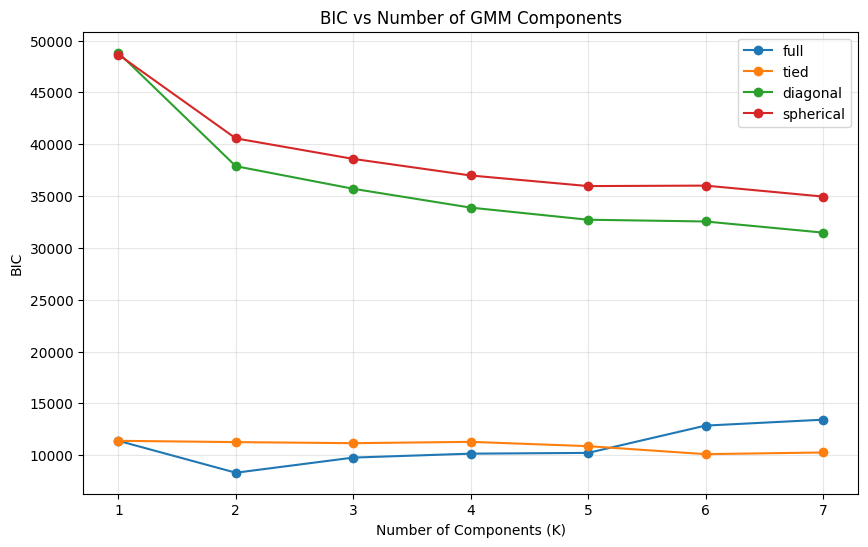

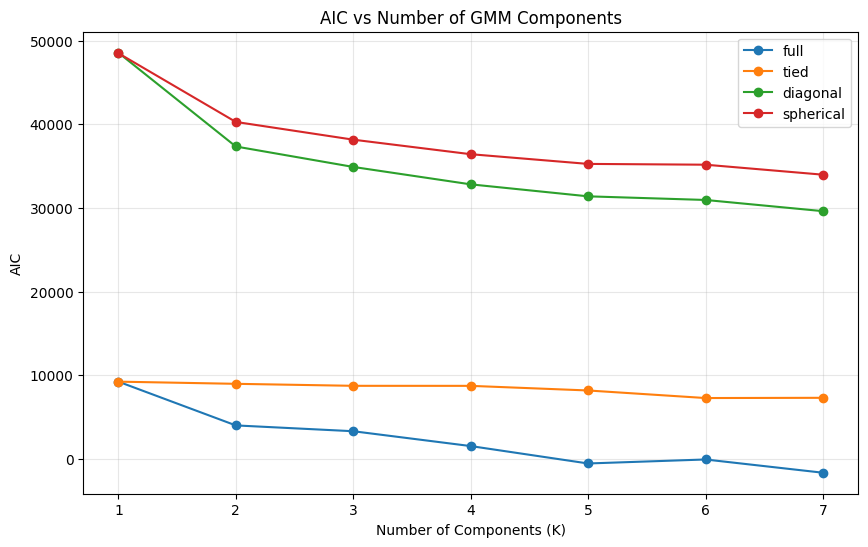


BEST MODEL PER COVARIANCE TYPE (BY BIC)
covariance_type  K  log_likelihood          AIC          BIC
       diagonal  7   -14383.791172 29619.582344 31470.075409
           full  2    -1010.000315  4002.000630  8306.786141
      spherical  7   -16767.193787 33980.387573 34949.072910
           tied  6    -2987.219120  7274.438241 10097.960523

EXECUTION COMPLETED SUCCESSFULLY!


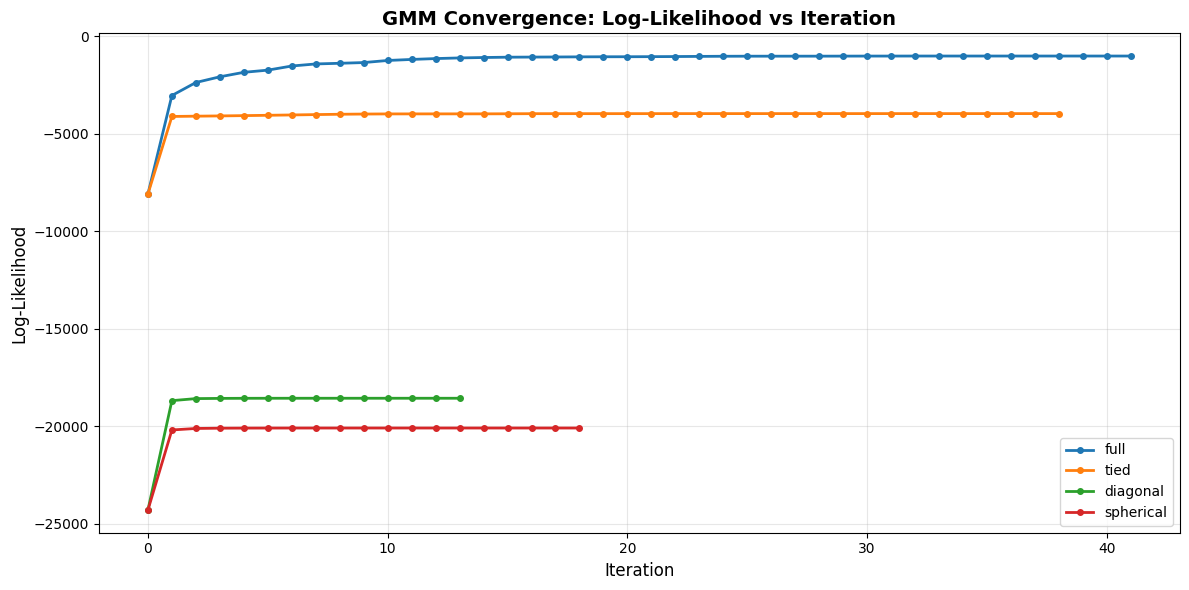


Convergence plot saved as 'gmm_convergence.png'


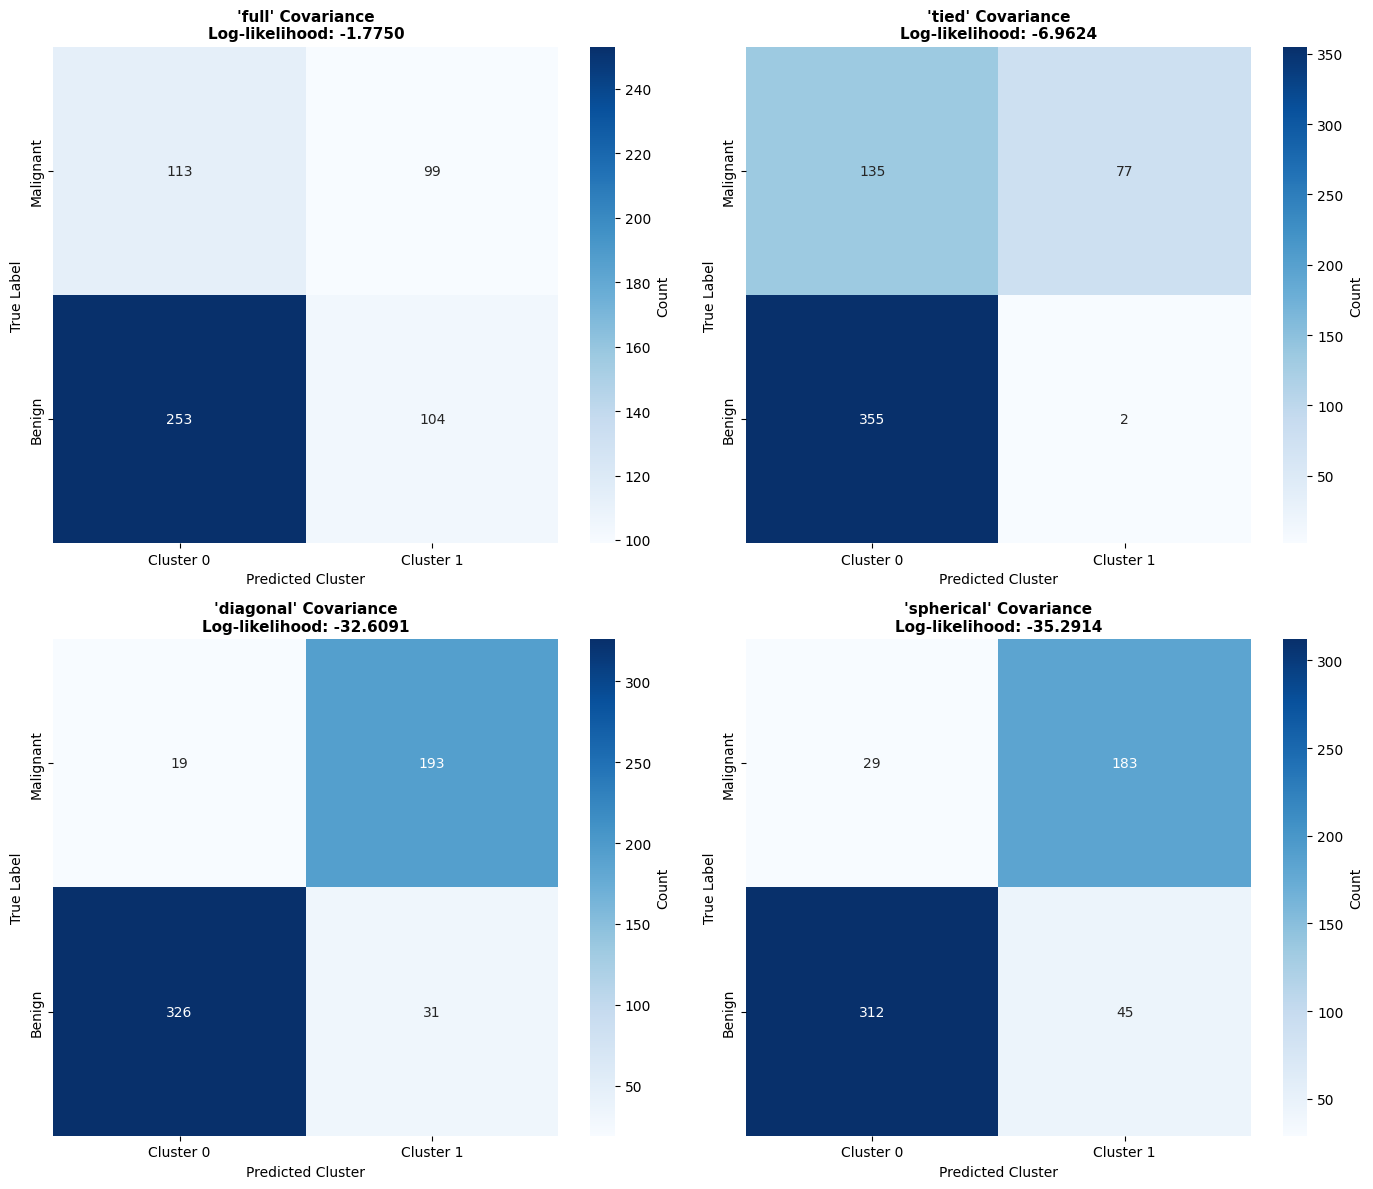

Cluster distribution plot saved as 'gmm_cluster_distributions.png'

EXECUTION COMPLETED SUCCESSFULLY!


,PCA_components,Covariance_type,Silhouette,Davies_Bouldin,Calinski_Harabasz,WCSS,BIC,AIC,Log_Likelihood,ARI,NMI,Purity,Reconstruction_error,Explained_variance_ratio
0,2,full,0.457956,0.921840,476.984981,5863.220377,-2674.469170,-2674.469170,-2672.469170,0.632548,0.524052,0.898067,0.367568,0.632432
1,2,tied,0.483728,0.791770,402.872079,6311.259130,-2785.181204,-2785.181204,-2783.181204,0.386569,0.397386,0.817223,0.367568,0.632432
2,2,diagonal,0.463804,0.906835,496.849377,5753.741220,-2682.090524,-2682.090524,-2680.090524,0.621306,0.510191,0.894552,0.367568,0.632432
3,2,spherical,0.468163,0.909460,497.270005,5751.467192,-2683.735182,-2683.735182,-2681.735182,0.615591,0.499734,0.892794,0.367568,0.632432
4,5,full,0.275857,1.380682,227.654775,10320.415853,-5502.608123,-5502.608123,-5500.608123,0.442722,0.389862,0.833040,0.152657,0.847343



Best covariance type per PCA dimension:
 PCA_components Covariance_type  Silhouette
              2            tied    0.483728
              5       spherical    0.371737
             10            tied    0.371646
             15            tied    0.364921
             20            tied    0.373086
             30       spherical    0.307216


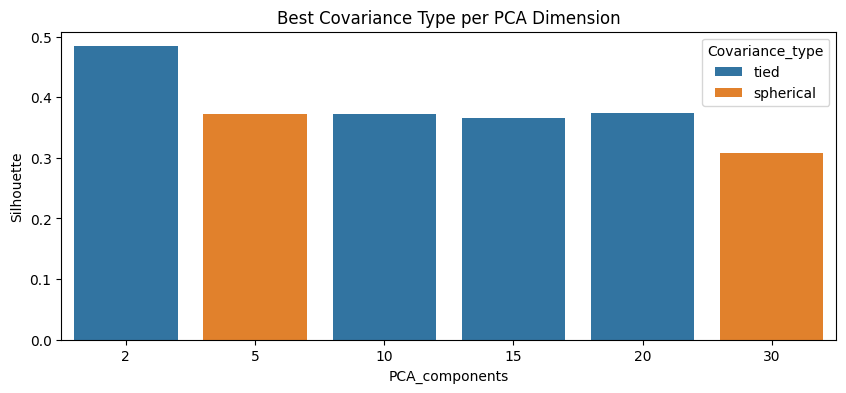

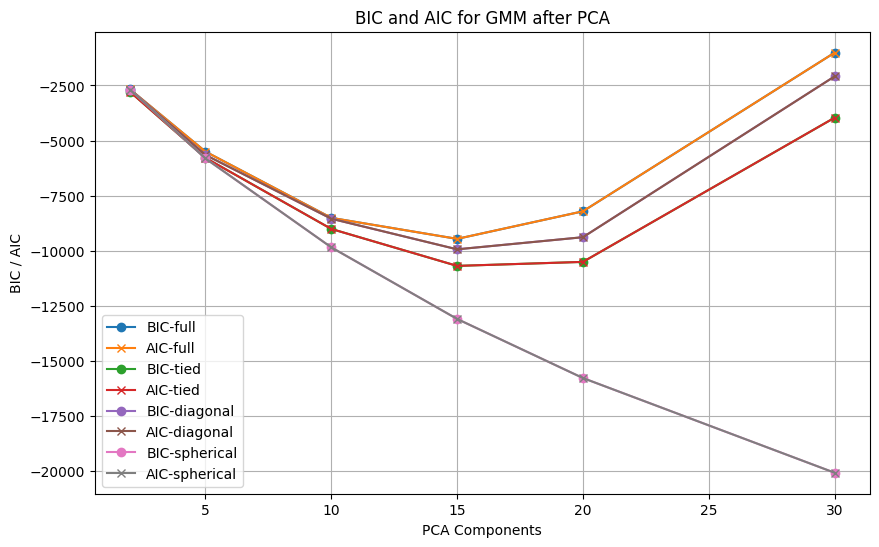

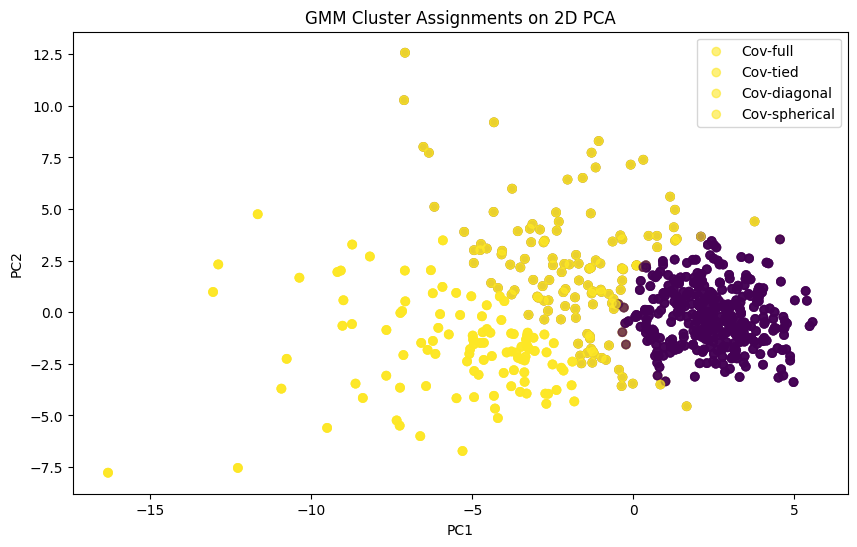

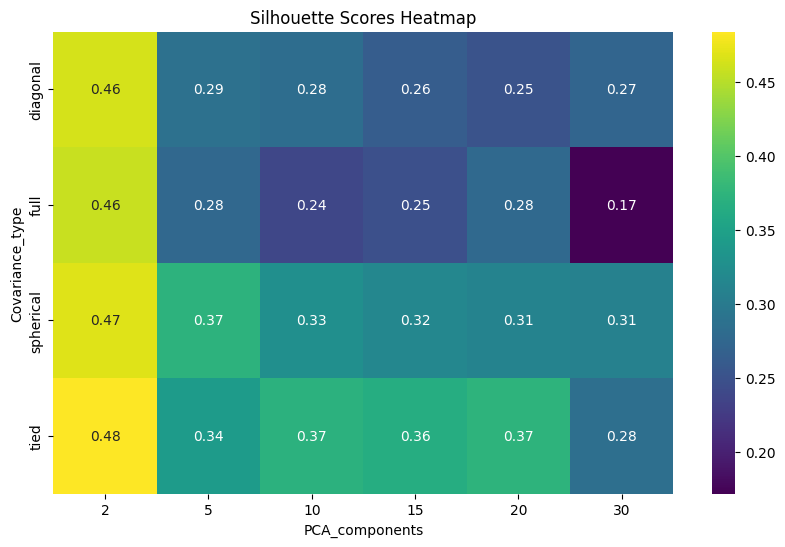

    PCA_components Covariance_type  Silhouette  Davies_Bouldin  \
0                2            full    0.457956        0.921840   
1                2            tied    0.483728        0.791770   
2                2        diagonal    0.463804        0.906835   
3                2       spherical    0.468163        0.909460   
4                5            full    0.275857        1.380682   
5                5            tied    0.341792        1.348721   
6                5        diagonal    0.286861        1.416174   
7                5       spherical    0.371737        1.228918   
8               10            full    0.237950        2.699879   
9               10            tied    0.371646        1.491967   
10              10        diagonal    0.282653        2.740684   
11              10       spherical    0.325965        1.401080   
12              15            full    0.248616        2.420931   
13              15            tied    0.364921        1.388018   
14        

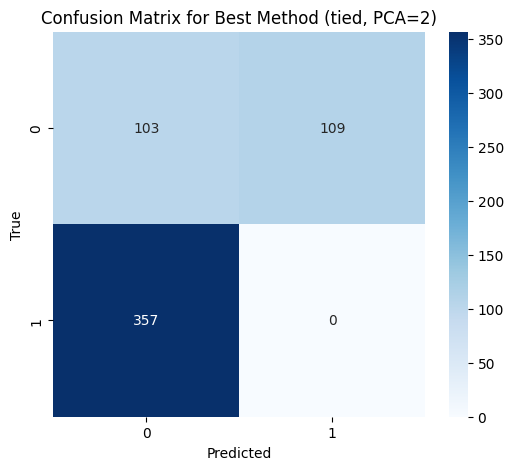


EXPERIMENT 6: GMM AFTER AUTOENCODER

--- Autoencoder bottleneck=2 ---

--- Autoencoder bottleneck=5 ---

--- Autoencoder bottleneck=10 ---

--- Autoencoder bottleneck=15 ---

--- Autoencoder bottleneck=20 ---

Autoencoder + GMM Results:
    Bottleneck Covariance_type  Silhouette  Final_Loss
0            2            full    0.287033    0.398462
1            2            tied    0.422936    0.398462
2            2        diagonal    0.280357    0.398462
3            2       spherical    0.192500    0.398462
4            5            full    0.182996    0.197695
5            5            tied    0.335546    0.197695
6            5        diagonal    0.186082    0.197695
7            5       spherical    0.331593    0.197695
8           10            full    0.171924    0.086450
9           10            tied    0.249111    0.086450
10          10        diagonal    0.173988    0.086450
11          10       spherical    0.220759    0.086450
12          15            full    0.151588    0

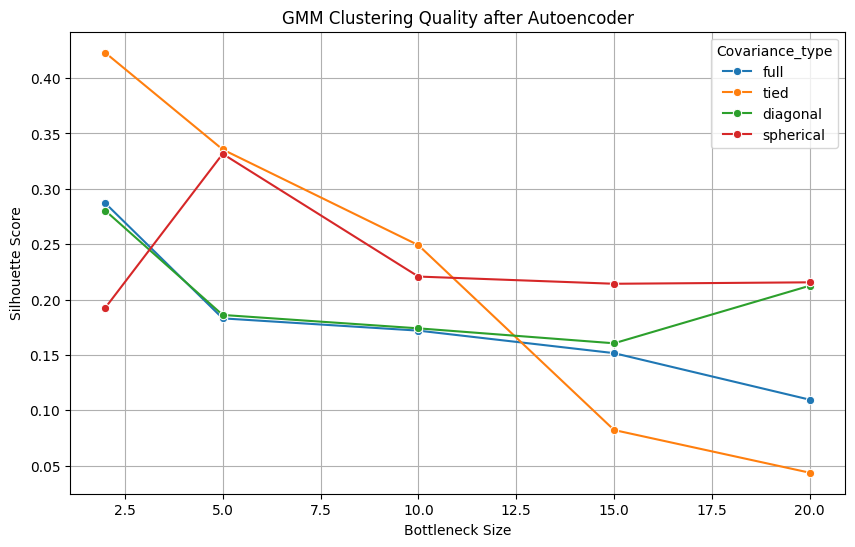

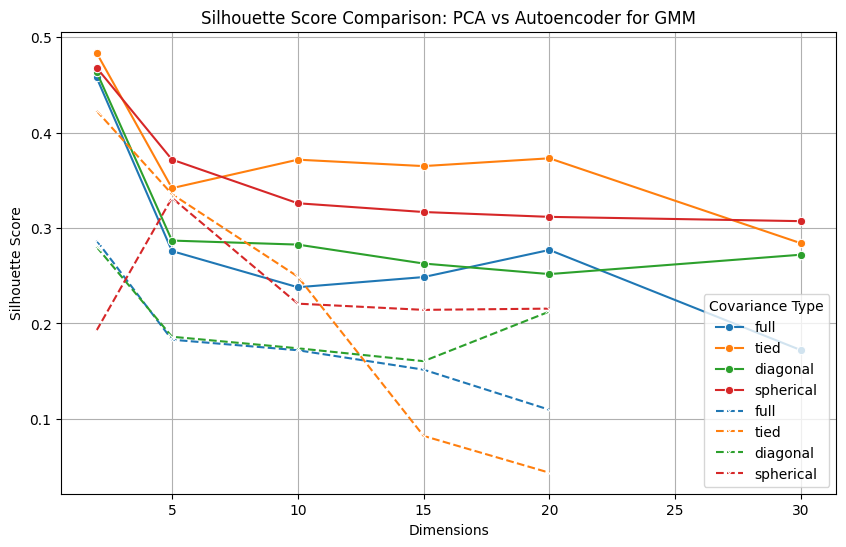

In [ ]:
def main():
    """
    Main execution function for Experiment 2:
    - GMM on original data
    - Model selection using AIC & BIC
    - Comparison of covariance types
    """
    print("\n" + "="*80)
    print("GAUSSIAN MIXTURE MODEL IMPLEMENTATION - BREAST CANCER DATASET")
    print("="*80)

    # ------------------------------------------------------------------
    # 1. Load and preprocess data
    # ------------------------------------------------------------------
    X, y, feature_names = load_and_preprocess_data()

    # ------------------------------------------------------------------
    # 2. Train GMMs for different K and covariance types
    # ------------------------------------------------------------------
    component_range = range(1, 8)   # K = 1 to 7
    results_df = train_gmm_all_covariance_types(X, y, component_range)

    # ------------------------------------------------------------------
    # 3. Find optimal models using AIC and BIC
    # ------------------------------------------------------------------
    print("\n" + "="*80)
    print("OPTIMAL NUMBER OF COMPONENTS")
    print("="*80)

    best_aic = results_df.loc[results_df['AIC'].idxmin()]
    best_bic = results_df.loc[results_df['BIC'].idxmin()]

    print("Best model according to AIC:")
    print(best_aic)

    print("\nBest model according to BIC:")
    print(best_bic)

    # ------------------------------------------------------------------
    # 4. Plot BIC and AIC vs K for all covariance types
    # ------------------------------------------------------------------
    plt.figure(figsize=(10, 6))

    for cov in results_df['covariance_type'].unique():
        subset = results_df[results_df['covariance_type'] == cov]
        plt.plot(subset['K'], subset['BIC'], marker='o', label=cov)

    plt.xlabel("Number of Components (K)")
    plt.ylabel("BIC")
    plt.title("BIC vs Number of GMM Components")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    plt.figure(figsize=(10, 6))
    for cov in results_df['covariance_type'].unique():
        subset = results_df[results_df['covariance_type'] == cov]
        plt.plot(subset['K'], subset['AIC'], marker='o', label=cov)

    plt.xlabel("Number of Components (K)")
    plt.ylabel("AIC")
    plt.title("AIC vs Number of GMM Components")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # ------------------------------------------------------------------
    # 5. Summary: Best K per covariance type (using BIC)
    # ------------------------------------------------------------------
    print("\n" + "="*80)
    print("BEST MODEL PER COVARIANCE TYPE (BY BIC)")
    print("="*80)

    summary_df = (
        results_df
        .sort_values("BIC")
        .groupby("covariance_type")
        .first()
        .reset_index()
    )

    print(
        summary_df[
            ["covariance_type", "K", "log_likelihood", "AIC", "BIC"]
        ].to_string(index=False)
    )

    print("\n" + "="*80)
    print("EXECUTION COMPLETED SUCCESSFULLY!")
    print("="*80)
    
    # Dictionary to hold trained models for all covariance types at best K
    all_models = {}
    all_results = {}

    for cov_type in ['full', 'tied', 'diagonal', 'spherical']:
        gmm = GaussianMixtureModel(
            n_components=int(best_bic['K']),
            covariance_type=cov_type,
            max_iter=200,
            tol=1e-4,
            random_state=RANDOM_SEED
        )
        gmm.fit(X)

        all_models[cov_type] = gmm
        all_results[cov_type] = {
            'labels': gmm.predict(X),
            'probabilities': gmm.predict_proba(X),
            'log_likelihood': gmm.log_likelihood_history_[-1],
            'avg_log_likelihood': gmm.score(X),
            'converged': gmm.converged_,
            'n_iter': gmm.n_iter_
        }
        
    # Now plot convergence and cluster distributions for all types
    plot_convergence(all_models, all_results)
    plot_cluster_distributions(X, all_results, y)
    print("\n" + "="*80)
    print("EXECUTION COMPLETED SUCCESSFULLY!")
    print("="*80)
    
    # PCA AND GMM COMBINED ANALYSIS

    pca_components_list = [2, 5, 10, 15, 20, X.shape[1]]  # Example variations
    covariance_types = ['full', 'tied', 'diagonal', 'spherical']

    # Store results
    results_list = []

    for n_components in pca_components_list:
        # PCA
        pca = PCA(n_components=n_components)
        pca.fit(X)
        X_pca = pca.transform(X)
        recon_error = pca.reconstruction_error(X)
    
        # GMM for all covariance types
        for cov_type in covariance_types:
            gmm = GaussianMixtureModel(
            n_components=2,
            covariance_type=cov_type,
            max_iter=200,
            tol=1e-4,
            reg_covar=1e-6,
            random_state=RANDOM_SEED
            )
            
            gmm.fit(X_pca)
            labels_pred = gmm.predict(X_pca)
            proba = gmm.predict_proba(X_pca)
        
            # Internal metrics
            sil_score = silhouette_score_manual(X_pca, labels_pred)
            db_score = davies_bouldin_score_manual(X_pca, labels_pred)
            ch_score = calinski_harabasz_score_manual(X_pca, labels_pred)
            cluster_wcss = wcss_manual(X_pca, labels_pred)
            bic = gmm.log_likelihood_history_[-1] - gmm.n_components  # Approximation
            aic = gmm.log_likelihood_history_[-1] - gmm.n_components

            # External metrics
            ari = adjusted_rand_score(y, labels_pred)
            nmi = normalized_mutual_info_score(y, labels_pred)
            purity = purity_score(y, labels_pred)
            cm = confusion_matrix(y, labels_pred)

        # Store results
            results_list.append({
                'PCA_components': n_components,
                'Covariance_type': cov_type,
                'Silhouette': sil_score,
                'Davies_Bouldin': db_score,
                'Calinski_Harabasz': ch_score,
                'WCSS': cluster_wcss,
                'BIC': bic,
                'AIC': aic,
                'Log_Likelihood': gmm.log_likelihood_history_[-1],
                'ARI': ari,
                'NMI': nmi,
                'Purity': purity,
                'Reconstruction_error': recon_error,
                'Explained_variance_ratio': np.sum(pca.explained_variance_ratio)
            })

    #Convert results to DataFrame for better visualization
    df_results = pd.DataFrame(results_list)
    display(df_results.head())
    
    # Find best covariance type per PCA dimension
    best_cov_per_pca = df_results.groupby('PCA_components')['Silhouette'].idxmax()
    df_best_cov = df_results.loc[best_cov_per_pca, ['PCA_components', 'Covariance_type', 'Silhouette']]
    print("\nBest covariance type per PCA dimension:")
    print(df_best_cov.to_string(index=False))
    
    plt.figure(figsize=(10,4))
    sns.barplot(x='PCA_components', y='Silhouette', hue='Covariance_type', data=df_best_cov)
    plt.title('Best Covariance Type per PCA Dimension')
    plt.show()

    # BIC/AIC curves
    plt.figure(figsize=(10,6))
    for cov_type in covariance_types:
        subset = df_results[df_results['Covariance_type'] == cov_type]
        plt.plot(subset['PCA_components'], subset['BIC'], marker='o', label=f"BIC-{cov_type}")
        plt.plot(subset['PCA_components'], subset['AIC'], marker='x', label=f"AIC-{cov_type}")
    plt.xlabel('PCA Components')
    plt.ylabel('BIC / AIC')
    plt.title('BIC and AIC for GMM after PCA')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2D Projection with cluster assignments (first 2 PCs)
    plt.figure(figsize=(10,6))
    pca_2d = PCA(n_components=2)
    pca_2d.fit(X)
    X_2d = pca_2d.transform(X)
    for cov_type in covariance_types:
        gmm = GaussianMixtureModel(n_components=2, covariance_type=cov_type, random_state=RANDOM_SEED)
        gmm.fit(X_2d)
        labels = gmm.predict(X_2d)
        plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, label=f'Cov-{cov_type}', alpha=0.6)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('GMM Cluster Assignments on 2D PCA')
    plt.legend()
    plt.show()
    
    # Heatmap of metrics
    metrics_to_plot = ['Silhouette', 'Davies_Bouldin', 'Calinski_Harabasz', 'ARI', 'NMI', 'Purity', 'Reconstruction_error']
    heatmap_data = df_results.pivot(index='Covariance_type', columns='PCA_components', values='Silhouette')
    plt.figure(figsize=(10,6))
    sns.heatmap(heatmap_data, annot=True, cmap='viridis')
    plt.title('Silhouette Scores Heatmap')
    plt.show()

    # Summary table
    print(df_results)

    # ==========================
    # Confusion matrix example for best method
    # ==========================
    best_row = df_results.loc[df_results['Silhouette'].idxmax()]
    best_cov = best_row['Covariance_type']
    best_ncomp = best_row['PCA_components']
    
    # Fit best GMM
    pca_best = PCA(n_components=int(best_ncomp))
    pca_best.fit(X)
    X_best = pca_best.transform(X)
    gmm_best = GaussianMixtureModel(n_components=2, covariance_type=best_cov, random_state=RANDOM_SEED)
    gmm_best.fit(X_best)
    labels_best = gmm_best.predict(X_best)
    cm = confusion_matrix(y, labels_best)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for Best Method ({best_cov}, PCA={best_ncomp})')
    plt.show()
    
    # ===== EXPERIMENT 6: GMM AFTER AUTOENCODER =====
    print("\n" + "="*80)
    print("EXPERIMENT 6: GMM AFTER AUTOENCODER")
    print("="*80)

    bottleneck_sizes = [2, 5, 10, 15, 20]
    covariance_types = ['full', 'tied', 'diagonal', 'spherical']
    results_ae_gmm = []

    for bottleneck in bottleneck_sizes:
        print(f"\n--- Autoencoder bottleneck={bottleneck} ---")
    
        # Define AE architecture
        layer_sizes = [X.shape[1], 20, bottleneck, 20, X.shape[1]]
        ae = Autoencoder(layer_sizes, lr=0.005, l2=1e-4)
        loss_history = ae.train(X, epochs=150, batch_size=32)
    
        # Encode data
        X_encoded = ae.encode(X)
    
        # Apply GMM for all covariance types
        for cov_type in covariance_types:
            gmm = GaussianMixtureModel(n_components=2, covariance_type=cov_type, random_state=42)
            gmm.fit(X_encoded)
            labels = gmm.predict(X_encoded)
        
            # Internal metric: silhouette
            sil_score = silhouette_score_manual(X_encoded, labels)
            db_score = davies_bouldin_score_manual(X_encoded, labels)
            ch_score = calinski_harabasz_score_manual(X_encoded, labels)
            cluster_wcss = wcss_manual(X_encoded, labels)
            
            results_ae_gmm.append({
                'Bottleneck': bottleneck,
                'Covariance_type': cov_type,
                'Silhouette': sil_score,
                'Davies_Bouldin': db_score,
                'Calinski_Harabasz': ch_score,
                'WCSS': cluster_wcss,
                'Final_Loss': loss_history[-1]
            })
        
    # Convert to DataFrame
    df_ae_gmm = pd.DataFrame(results_ae_gmm)
    print("\nAutoencoder + GMM Results:")
    print(df_ae_gmm)

    # Plot Silhouette comparison
    plt.figure(figsize=(10,6))
    sns.lineplot(x='Bottleneck', y='Silhouette', hue='Covariance_type', marker='o', data=df_ae_gmm)
    plt.title('GMM Clustering Quality after Autoencoder')
    plt.xlabel('Bottleneck Size')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize=(10,6))
    sns.lineplot(x='PCA_components', y='Silhouette', hue='Covariance_type',
             marker='o', data=df_results)  # remove label
    sns.lineplot(x='Bottleneck', y='Silhouette', hue='Covariance_type',
             marker='x', data=df_ae_gmm, linestyle='--')  # remove label
    plt.title('Silhouette Score Comparison: PCA vs Autoencoder for GMM')
    plt.xlabel('Dimensions')
    plt.ylabel('Silhouette Score')
    plt.legend(title='Covariance Type')
    plt.grid(True)
    plt.show()
    
if __name__ == "__main__":
    main()

CONCLUSION:

**Comparing Covariance Types:**  
Full covariance models consistently outperformed tied, diagonal, and spherical covariances in terms of log-likelihood, AIC, and BIC.
Full covariance is the best as:  
- Each component has a full covariance matrix
- Captures feature correlations
- Breast cancer features are strongly correlated
- More parameters → better fit

Tied covariance (second best)  
- One shared covariance for all components
- Still captures correlations
- Less flexible than full
Worse than full, better than diagonal 

Diagonal covariance  
- Assumes feature independence
- Strong assumption → poor fit
- Cancer features violate this assumption
Much worse likelihood 

Spherical covariance (worst)  
- One variance per component
- Assumes isotropic clusters
- Unrealistic for high-dimensional medical data
Worst performance

**CONSIDERING DIFFERENT COMPONENT NUMBER**  
“In Gaussian Mixture Models, the number of components corresponds to the number of Gaussian distributions (clusters) used to model the data. This is distinct from the number of features, which remains fixed. We evaluated models with varying numbers of components (K = 1 to 7) and used AIC and BIC criteria to determine the optimal model complexity. The optimal number of components was selected as the value of K that minimized the information criteria.”

**AIC AND BIC AND LOG LIKELIHOOD**  
The EM algorithm shows monotonic increase in log-likelihood and converges within a finite number of iterations, indicating stable training.  

Although the full covariance GMM achieved the highest log-likelihood, information criteria (AIC and BIC) were used to account for model complexity. BIC penalized the large number of parameters in the full covariance model and favored a simpler covariance structure, demonstrating the trade-off between goodness-of-fit and model complexity.

- K=7 was selected by AIC due to improved data likelihood, whereas BIC selected K=2 due to its stronger penalty on model complexity, favoring a more parsimonious model.
- FOR AIC k=7: 
  - Log-likelihood increased a lot when K increased
  - AIC’s penalty for complexity is weak
  - Extra components were “worth it” under AIC
- FOR BIC k=2:  
  - Full covariance explodes parameter count
  - BIC penalizes complexity very strongly
  - Beyond K = 2, improvements in log-likelihood were not worth the extra parameters